In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)


In [2]:
folders = ['EDA','Preprocessing','Model','Evaluation','Importance']
for f in folders:
    os.makedirs(f, exist_ok=True)


In [4]:
# =============================================================================
# LOAD DATASET
# =============================================================================

df = pd.read_csv('Thesis_Cricket_Dataset.csv')

print("Shape:", df.shape)
df.head()


Shape: (1979, 298)


,match_code,match_type,team1,team2,venue,date,series,toss_winner,team1_bat_first,match_result,...,team2_bowl10_runs,team2_bowl10_wickets,team2_bowl10_economy,team2_bowl11_name,team2_bowl11_overs,team2_bowl11_maidens,team2_bowl11_runs,team2_bowl11_wickets,team2_bowl11_economy,match_winner
0,2950,ODI,West Indies,England,Kensington Oval,27/03/2009,2828\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nPlayers\nS...,West Indies,1,117 West Indies won by 8 wickets,...,76.0,3.0,0.0,Stuart Broad,0.0,0.0,2.0,0.0,0.0,West Indies
1,2951,ODI,West Indies,England,Kensington Oval,29/03/2009,2829\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nPlayers\nS...,England,1,1 England won by 9 wickets,...,15.0,0.0,0.0,Nikita Miller,0.0,10.0,13.0,1.0,0.0,England
2,2952,ODI,Ireland,Scotland,Willowmoore Park,01/04/2009,2009 ICC World Cup,Ireland,1,7 Ireland won by 7 wickets,...,14.0,0.0,0.0,Jan Stander,0.0,22.0,13.0,0.0,2.0,Ireland
3,2953,ODI,Netherlands,Kenya,Senwes Park,01/04/2009,2009 ICC World Cup,Kenya,1,8 Netherlands won by 7 wickets,...,19.0,2.0,0.0,Nehemiah Odhiambo,0.0,29.0,17.0,1.0,2.0,Netherlands
4,2954,ODI,South Africa,Australia,Players\nSeries\nMatches\n\nStatistics \r\n\t\...,03/04/2009,2832\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nPlayers\nS...,Australia,1,7 Australia won by 141 runs,...,2.0,0.0,0.0,Nathan Hauritz,0.0,20.0,11.0,3.0,0.0,Australia


In [5]:
# =============================================================================
# BASIC INFO
# =============================================================================

print(df.info())
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1979 entries, 0 to 1978
Columns: 298 entries, match_code to match_winner
dtypes: float64(148), int64(74), str(76)
memory usage: 4.5 MB
None

Missing values:
 team2_bat11_runs         18
team2_bat11_name         18
team2_bat11_fours        18
team2_bat11_dismissal    18
team2_bat11_sixes        18
dtype: int64

Duplicate rows: 0


In [6]:
# =============================================================================
# WINNER DISTRIBUTION TABLE
# =============================================================================

winner_counts = df['match_winner'].value_counts()
winner_counts.head(15)


match_winner
India           215
Australia       186
England         162
Sri Lanka       161
South Africa    153
Pakistan        139
New Zealand     134
Bangladesh      116
Afghanistan      83
Ireland          71
No Result        67
Scotland         65
Zimbabwe         63
West Indies      54
West             42
Name: count, dtype: int64

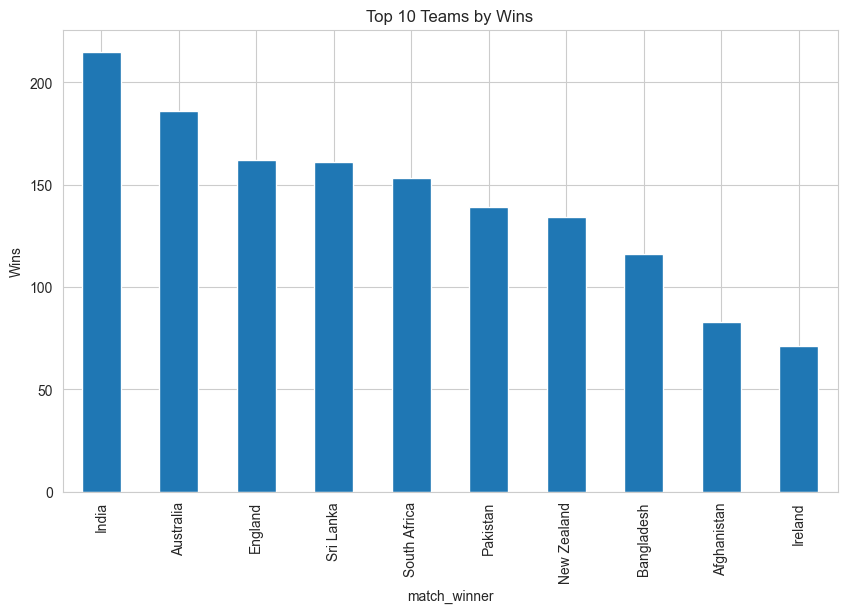

In [7]:
# =============================================================================
# BAR PLOT - TOP WINNERS
# =============================================================================

winner_counts.head(10).plot(kind='bar')
plt.title("Top 10 Teams by Wins")
plt.ylabel("Wins")
plt.show()


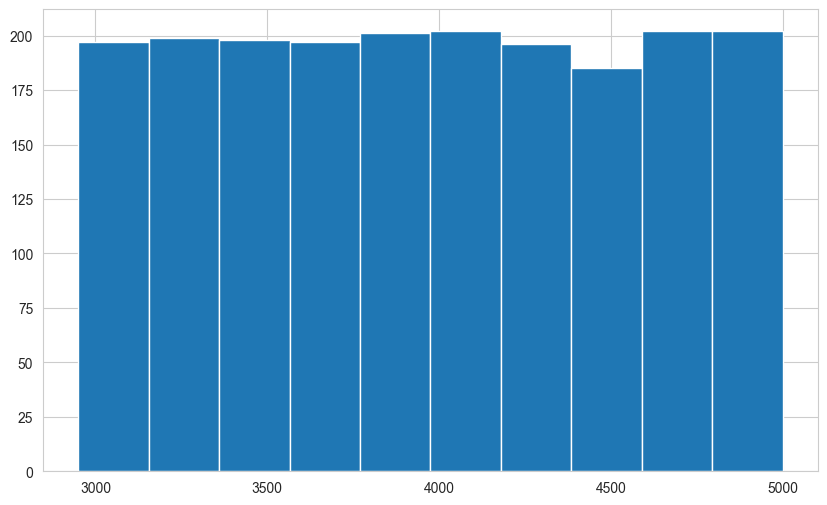

In [8]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols[0]].hist()
plt.savefig("EDA/sample_hist.png")
plt.show()


In [9]:
# =============================================================================
# CLEANING
# =============================================================================

df = df[df['match_winner'].notna()].drop_duplicates()



In [10]:
# =============================================================================
# ENCODING
# =============================================================================

le_team = LabelEncoder()
le_venue = LabelEncoder()
le_win = LabelEncoder()

df['team1_enc']=le_team.fit_transform(df['team1'])
df['team2_enc']=le_team.fit_transform(df['team2'])
df['venue_enc']=le_venue.fit_transform(df['venue'].astype(str))
df['winner_enc']=le_win.fit_transform(df['match_winner'])



In [11]:


# =============================================================================
# LEAKAGE REMOVAL  (FIXED)
# =============================================================================

# words that indicate post-match info (cannot be used for prediction)
leak_words = [
    'run','score','wicket','total','difference',
    'strike','economy','over','ball'
]

drop_cols = []

for c in df.columns:
    if any(word in c.lower() for word in leak_words):
        drop_cols.append(c)

print("Removed leakage columns:", len(drop_cols))
print(drop_cols[:10])   # preview first few

df_model = df.drop(columns=drop_cols)



Removed leakage columns: 132
['team1_bat1_runs', 'team1_bat1_balls', 'team1_bat2_runs', 'team1_bat2_balls', 'team1_bat3_runs', 'team1_bat3_balls', 'team1_bat4_runs', 'team1_bat4_balls', 'team1_bat5_runs', 'team1_bat5_balls']


In [12]:
X = df_model.select_dtypes(include=np.number)
X = X.drop(columns=['winner_enc'])

y = df_model['winner_enc']

print("Features used:", X.shape[1])


Features used: 93


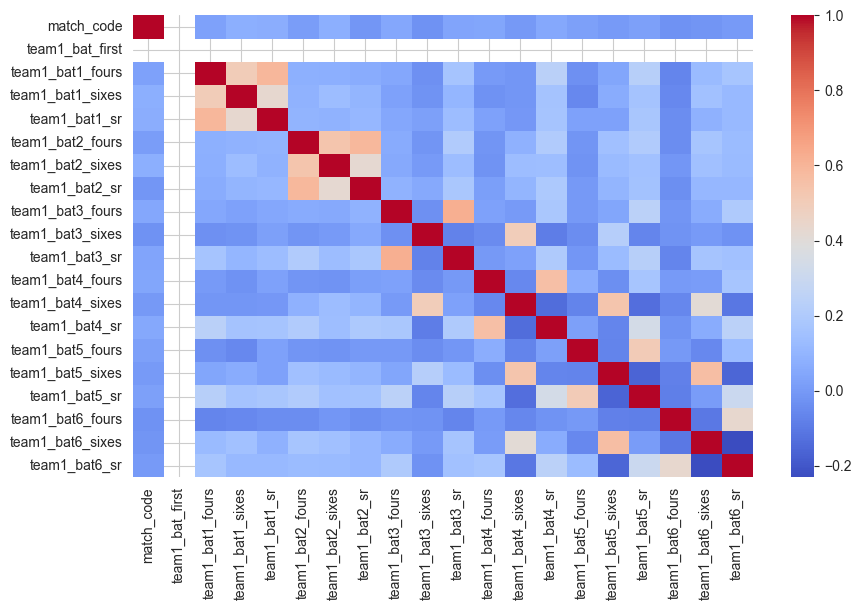

In [13]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

sns.heatmap(X.iloc[:,:20].corr(), cmap='coolwarm')
plt.savefig("EDA/corr.png")
plt.show()



In [119]:
# =============================================================================
# REMOVE RARE CLASSES
# =============================================================================

counts=y.value_counts()
valid=counts[counts>=3].index

mask=y.isin(valid)

X=X[mask]
y=y[mask]

y=LabelEncoder().fit_transform(y)



In [20]:
# =============================================================================
# TRAIN TEST SPLIT
# =============================================================================

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,stratify=y,random_state=42)


In [19]:
# =============================================================================
# TRAIN MODEL  (FIXED for new XGBoost versions)
# =============================================================================

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_lambda=10,
    reg_alpha=4,
    min_child_weight=6,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=20   # ✅ moved here
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)




ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25], got [ 0  1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]

In [16]:
# =============================================================================
# ACCURACY
# =============================================================================

train_acc=accuracy_score(y_train,model.predict(X_train))*100
test_acc=accuracy_score(y_test,model.predict(X_test))*100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")




NameError: name 'model' is not defined

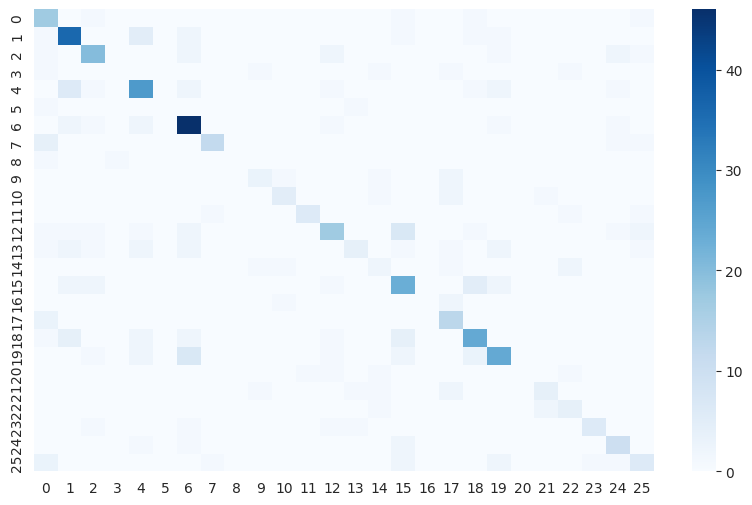

In [123]:
sns.heatmap(confusion_matrix(y_test,model.predict(X_test)), cmap='Blues')
plt.savefig("Evaluation/confusion.png")
plt.show()


In [124]:
print(classification_report(y_test,model.predict(X_test)))



              precision    recall  f1-score   support

           0       0.49      0.81      0.61        21
           1       0.68      0.77      0.72        47
           2       0.69      0.69      0.69        29
           3       0.00      0.00      0.00         5
           4       0.64      0.66      0.65        41
           5       0.00      0.00      0.00         2
           6       0.69      0.85      0.76        54
           7       0.86      0.67      0.75        18
           8       0.00      0.00      0.00         2
           9       0.50      0.43      0.46         7
          10       0.62      0.56      0.59         9
          11       0.86      0.67      0.75         9
          12       0.65      0.50      0.57        34
          13       0.57      0.24      0.33        17
          14       0.25      0.29      0.27         7
          15       0.53      0.66      0.59        35
          16       0.00      0.00      0.00         3
          17       0.54    

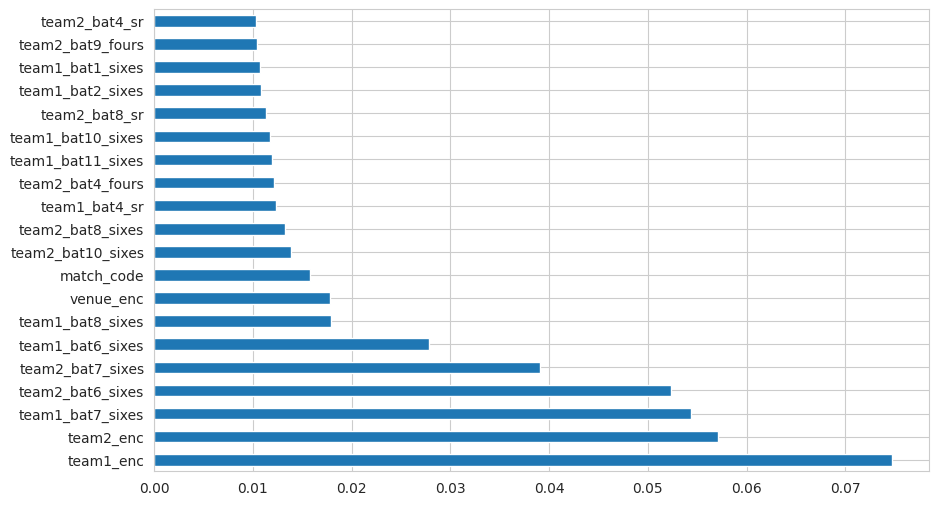

In [125]:
imp=pd.Series(model.feature_importances_,index=X.columns)
imp.nlargest(20).plot(kind='barh')
plt.savefig("Importance/top_features.png")
plt.show()



In [126]:
imp.sort_values(ascending=False).head(15)


,0
team1_enc,0.074725
team2_enc,0.057090
team1_bat7_sixes,0.054337
team2_bat6_sixes,0.052313
team2_bat7_sixes,0.039096
team1_bat6_sixes,0.027888
team1_bat8_sixes,0.017895
venue_enc,0.017843
match_code,0.015838
team2_bat10_sixes,0.013918


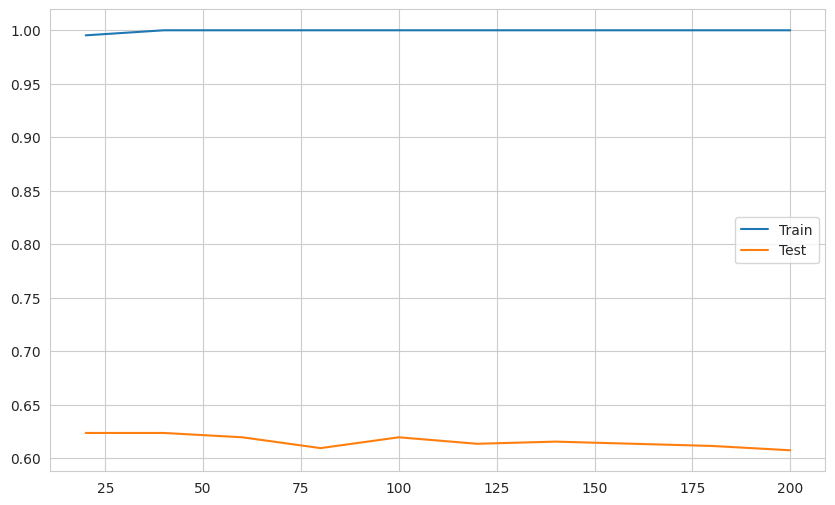

In [127]:
tr,te=[],[]
for n in range(20,220,20):
    m=XGBClassifier(n_estimators=n,max_depth=4)
    m.fit(X_train,y_train)
    tr.append(accuracy_score(y_train,m.predict(X_train)))
    te.append(accuracy_score(y_test,m.predict(X_test)))

plt.plot(range(20,220,20),tr,label='Train')
plt.plot(range(20,220,20),te,label='Test')
plt.legend()
plt.savefig("Model/learning_curve.png")
plt.show()



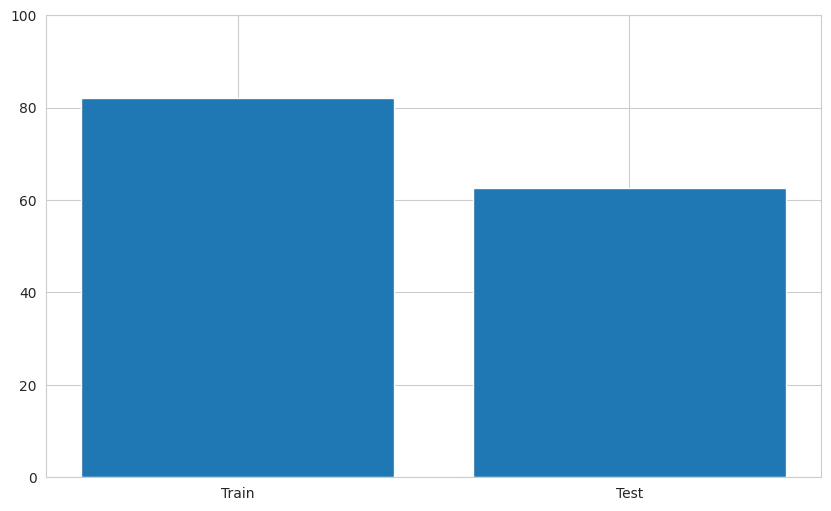

In [128]:
plt.bar(['Train','Test'],[train_acc,test_acc])
plt.ylim(0,100)
plt.savefig("Evaluation/train_test.png")
plt.show()



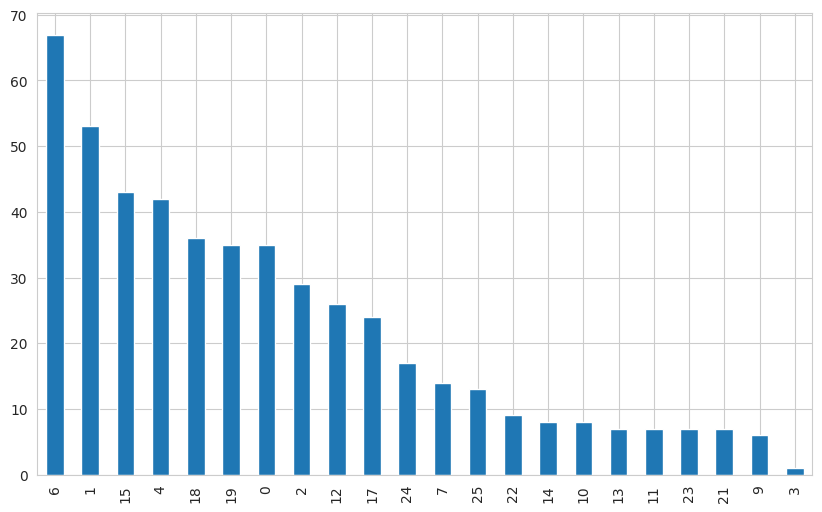

In [129]:
pd.Series(model.predict(X_test)).value_counts().plot(kind='bar')
plt.savefig("Evaluation/pred_dist.png")
plt.show()



In [130]:
pd.DataFrame({
    "Metric":["Train Accuracy","Test Accuracy"],
    "Value":[f"{train_acc:.2f}%",f"{test_acc:.2f}%"]
})


,Metric,Value
0,Train Accuracy,82.04%
1,Test Accuracy,62.55%


In [131]:
from sklearn.preprocessing import LabelBinarizer

# 1. Calculate predicted probabilities for each class
y_pred_proba = model.predict_proba(X_test)

# 2. One-hot encode the true labels
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)

print(f"Shape of predicted probabilities: {y_pred_proba.shape}")
print(f"Shape of binarized true labels: {y_test_binarized.shape}")

Shape of predicted probabilities: (494, 26)
Shape of binarized true labels: (494, 26)


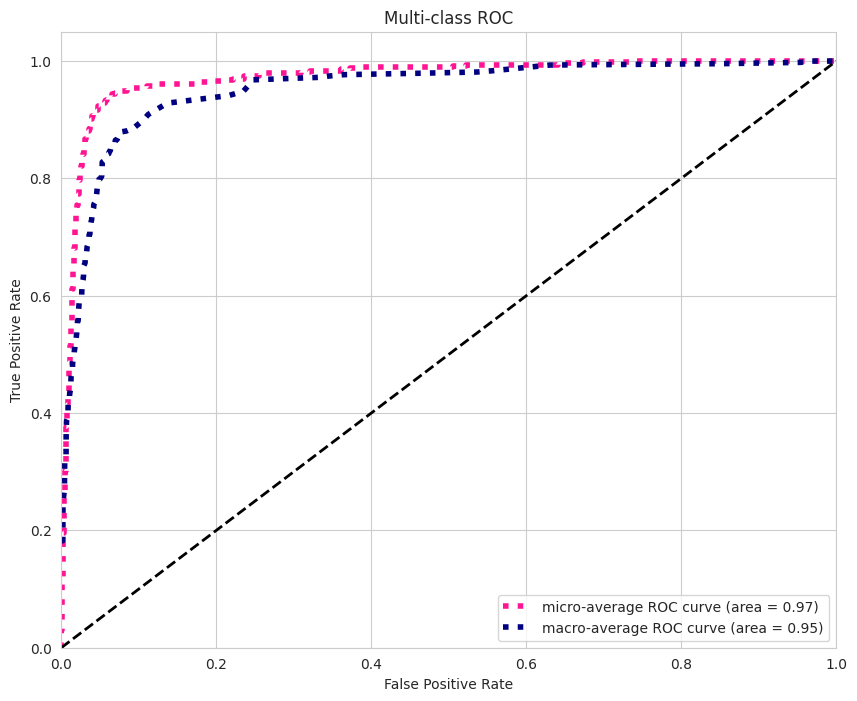

Micro-average AUC: 0.97
Macro-average AUC: 0.95


In [132]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Number of classes
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

# Plot individual class ROC curves (optional, can be commented out for cleaner plot)
# for i in range(n_classes):
#     plt.plot(fpr[i], tpr[i], lw=2,
#              label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.savefig("Evaluation/multi_class_roc_auc.png")
plt.show()

print(f"Micro-average AUC: {roc_auc['micro']:.2f}")
print(f"Macro-average AUC: {roc_auc['macro']:.2f}")
